In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
import nltk
nltk.download('stopwords')
nltk.download('rslp')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\86155\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\86155\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

# Reading Data

In [2]:
olist_customer = pd.read_csv('olist_customers_dataset.csv')
olist_geolocation = pd.read_csv('olist_geolocation_dataset.csv')
olist_orders = pd.read_csv('olist_orders_dataset.csv')
olist_order_items = pd.read_csv('olist_order_items_dataset.csv')
olist_order_payments = pd.read_csv('olist_order_payments_dataset.csv')
olist_order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
olist_products = pd.read_csv('olist_products_dataset.csv')
olist_sellers = pd.read_csv('olist_sellers_dataset.csv')

In [3]:
# Collections for each dataset
datasets = [olist_customer, olist_geolocation, olist_orders, olist_order_items, olist_order_payments,
            olist_order_reviews, olist_products, olist_sellers]
names = ['olist_customer', 'olist_geolocation', 'olist_orders', 'olist_order_items', 'olist_order_payments',
         'olist_order_reviews', 'olist_products', 'olist_sellers']

# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names
data_info['n_rows'] = [df.shape[0] for df in datasets]
data_info['n_cols'] = [df.shape[1] for df in datasets]
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets]
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

data_info.style.background_gradient()

,dataset,n_rows,n_cols,null_amount,qty_null_columns,null_columns
0,olist_customer,99441,5,0,0,
1,olist_geolocation,1000163,5,0,0,
2,olist_orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,olist_order_items,112650,7,0,0,
4,olist_order_payments,103886,5,0,0,
5,olist_order_reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
6,olist_products,32951,9,2448,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,olist_sellers,3095,4,0,0,


In [4]:
df_overview_list = []
name_col = []

for name, df in zip(names, datasets):
    for col in df.columns:
        num_nulls = df[col].isnull().sum()  # 缺失值数量
        percent_null = (num_nulls / len(df)) * 100  # 缺失值占比
        dtype = df[col].dtype  # 数据类型
        num_unique_categories = df[col].nunique() if df[col].dtype == 'object' else 0  # 类别数量

        df_overview_list.append([name, col, num_nulls, percent_null, dtype, num_unique_categories])
        
df_overview = pd.DataFrame(df_overview_list, columns=['dataset_name', 'feature', 'num_nulls', 'percent_null', 'dtype', 'num_unique_categories'])
df_overview

,dataset_name,feature,num_nulls,percent_null,dtype,num_unique_categories
0,olist_customer,customer_id,0,0.000000,object,99441
1,olist_customer,customer_unique_id,0,0.000000,object,96096
2,olist_customer,customer_zip_code_prefix,0,0.000000,int64,0
3,olist_customer,customer_city,0,0.000000,object,4119
4,olist_customer,customer_state,0,0.000000,object,27
5,olist_geolocation,geolocation_zip_code_prefix,0,0.000000,int64,0
6,olist_geolocation,geolocation_lat,0,0.000000,float64,0
7,olist_geolocation,geolocation_lng,0,0.000000,float64,0
8,olist_geolocation,geolocation_city,0,0.000000,object,8011
9,olist_geolocation,geolocation_state,0,0.000000,object,27


# Natural Language Processing

In [5]:
df_comments = olist_order_reviews.loc[:, ['review_score', 'review_comment_message']]
df_comments = df_comments.dropna(subset=['review_comment_message'])
df_comments = df_comments.reset_index(drop=True)
print(f'Dataset shape: {df_comments.shape}')
df_comments.columns = ['score', 'comment']
df_comments.head()

Dataset shape: (40977, 2)


,score,comment
0,5,Recebi bem antes do prazo estipulado.
1,5,Parabéns lojas lannister adorei comprar pela I...
2,4,aparelho eficiente. no site a marca do aparelh...
3,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
4,5,"Vendedor confiável, produto ok e entrega antes..."


去除换行符，替换为空格

In [6]:
def re_linebreak(text_list):
    return [re.sub('[\n\r]', ' ', r) for r in text_list]

In [7]:
reviews = list(df_comments['comment'].values)
reviews_linebreak = re_linebreak(reviews)
df_comments['re_linebreak'] = reviews_linebreak
print(reviews[48])
print(reviews_linebreak[48])

Estava faltando apenas um produto, eu recebi hoje , muito obrigada!
Tudo certo!

Att 

Elenice.
Estava faltando apenas um produto, eu recebi hoje , muito obrigada!  Tudo certo!    Att     Elenice.


去除URL，替换为' link '

In [8]:
def re_hyperlinks(text_list):
    pattern = 'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    return [re.sub(pattern, ' link ', r) for r in text_list]

In [9]:
reviews_hyperlinks = re_hyperlinks(reviews_linebreak)
df_comments['re_hyperlinks'] = reviews_hyperlinks
print(reviews_linebreak[10607])
print(reviews_hyperlinks[10607])

comprei o produto pela cor ilustrada pelo site da loja americana, no site mostra ser preto http://prntscr.com/jkx7hr quando o produto chegou aqui veio todos com a mesma cor, tabaco http://prntscr.com/
comprei o produto pela cor ilustrada pelo site da loja americana, no site mostra ser preto  link  quando o produto chegou aqui veio todos com a mesma cor, tabaco  link 


日期替换为' data '

In [10]:
def re_dates(text_list):
    pattern = '([0-2][0-9]|(3)[0-1])(\/|\.)(((0)[0-9])|((1)[0-2]))(\/|\.)\d{2,4}'
    return [re.sub(pattern, ' data ', r) for r in text_list]

In [11]:
reviews_dates = re_dates(reviews_hyperlinks)
df_comments['re_dates'] = reviews_dates
print(reviews_hyperlinks[567])
print(reviews_dates[567])

ENTREGA MUITO DEMORADA, COMPREI EM 26/03/2018 E ATÉ AGORA NÃO RECEBI OS PRODUTOS
ENTREGA MUITO DEMORADA, COMPREI EM  data  E ATÉ AGORA NÃO RECEBI OS PRODUTOS


钱替换为' dinheiro '

In [12]:
def re_money(text_list):
    pattern = '[R]{0,1}\$[ ]{0,}\d+(,|\.)\d+'
    return [re.sub(pattern, ' dinheiro ', r) for r in text_list]

In [13]:
reviews_money = re_money(reviews_dates)
print(reviews_dates[45])
print(reviews_money[45])

Este foi o pedido  Balde Com 128 Peças - Blocos De Montar 2 un - R$ 25,00 cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras 36 Peças Crianças 1 un - R$ 35,90 (ESTE FOI ENTREG
Este foi o pedido  Balde Com 128 Peças - Blocos De Montar 2 un -  dinheiro  cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras 36 Peças Crianças 1 un -  dinheiro  (ESTE FOI ENTREG


数字替换为' numero '

In [14]:
def re_numbers(text_list):
    return [re.sub('[0-9]+', ' numero ', r) for r in text_list]

In [15]:
reviews_numbers = re_numbers(reviews_money)
df_comments['re_numbers'] = reviews_numbers
print(reviews_money[45])
print(reviews_numbers[45])

Este foi o pedido  Balde Com 128 Peças - Blocos De Montar 2 un -  dinheiro  cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras 36 Peças Crianças 1 un -  dinheiro  (ESTE FOI ENTREG
Este foi o pedido  Balde Com  numero  Peças - Blocos De Montar  numero  un -  dinheiro  cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras  numero  Peças Crianças  numero  un -  dinheiro  (ESTE FOI ENTREG


否定词替换为' negação '

In [16]:
def re_negation(text_list):
    return [re.sub('([nN][ãÃaA][oO]|[ñÑ]| [nN] )', ' negação ', r) for r in text_list]

In [17]:
reviews_negation = re_negation(reviews_numbers)
df_comments['re_negation'] = reviews_negation
print(reviews_numbers[11])
print(reviews_negation[11])

Não gostei ! Comprei gato por lebre
 negação  gostei ! Comprei gato por lebre


特殊字符替换为空格

In [18]:
def re_special_chars(text_list):
    return [re.sub('\W', ' ', r) for r in text_list]

In [19]:
reviews_special_chars = re_special_chars(reviews_negation)
df_comments['re_special_chars'] = reviews_special_chars
print(reviews_negation[133])
print(reviews_special_chars[133])

Cada vez que compro mais fico satisfeita parabéns pela honestidade com seus clientes 👏👏👏👏?
Cada vez que compro mais fico satisfeita parabéns pela honestidade com seus clientes      


去除多余空格

In [20]:
def re_whitespaces(text_list):
    white_spaces = [re.sub('\s+', ' ', r) for r in text_list]
    white_spaces_end = [re.sub('[ \t]+$', '', r) for r in white_spaces]
    return white_spaces_end

In [21]:
reviews_whitespaces = re_whitespaces(reviews_special_chars)
df_comments['re_whitespaces'] = reviews_whitespaces
print(reviews_special_chars[3])
print(reviews_whitespaces[3])

Mas um pouco  travando   pelo valor ta Boa   
Mas um pouco travando pelo valor ta Boa


Stopwords

In [81]:
import nltk
nltk.download('stopwords')
nltk.download('rslp')
pt_stopwords = stopwords.words('portuguese')
print(f'Total portuguese stopwords in the nltk.corpous module: {len(pt_stopwords)}')
pt_stopwords[:10]

Total portuguese stopwords in the nltk.corpous module: 207


[nltk_data] Downloading package stopwords to
[nltk_data]     /nfs/home/Tyrants/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /nfs/home/Tyrants/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as']

In [82]:
def stopwords_removal(text):
    return [c.lower() for c in text.split() if c.lower() not in pt_stopwords]

In [83]:
reviews_stopwords = [' '.join(stopwords_removal(review)) for review in reviews_whitespaces]
df_comments['stopwords_removed'] = reviews_stopwords
print(reviews_whitespaces[3])
print(reviews_stopwords[3])

Mas um pouco travando pelo valor ta Boa
pouco travando valor ta boa


Stemming

In [84]:
def stemming(text, stemmer=RSLPStemmer()):
    return [stemmer.stem(c) for c in text.split()]

In [85]:
reviews_stemmer = [' '.join(stemming(review)) for review in reviews_stopwords]
df_comments['stemming'] = reviews_stemmer
print(reviews_stopwords[3])
print(reviews_stemmer[3])

pouco travando valor ta boa
pouc trav val ta boa


Feature Extraction

1. 使用`CountVectorizer`将文本数据转换为词袋（Bag of Words, BoW）表示。通过`fit_transform()`统计每个词语在文本中出现的次数，生成一个词频矩阵。

In [86]:
def extract_features_from_corpus(corpus, vectorizer, df=False):
    
    # Extracting features
    corpus_features = vectorizer.fit_transform(corpus).toarray()
    features_names = vectorizer.get_feature_names_out()
    
    # Transforming into a dataframe to give interpretability to the process
    df_corpus_features = None
    if df:
        df_corpus_features = pd.DataFrame(corpus_features, columns=features_names)
    
    return corpus_features, df_corpus_features

`‌max_features‌=300`: 只保留出现频率最高的 300 个单词

`min_df=7`: 单词至少出现在7个文档中才会被保留

`max_df=0.8`: 单词出现在80%以上的文档时会被忽略

`stop_words=pt_stopwords`: 使用葡萄牙语停用词

In [87]:
count_vectorizer = CountVectorizer(max_features=300, min_df=7, max_df=0.8, stop_words=pt_stopwords)

# Extracting features for the corpus
countv_features, df_countv_features = extract_features_from_corpus(reviews_stemmer, count_vectorizer, df=True)
print(f'Shape of countv_features matrix: {countv_features.shape}\n')
df_countv_features.head()

Shape of countv_features matrix: (40977, 300)



,abr,acab,ach,acontec,acord,ador,adquir,agor,aguard,aind,...,vei,vem,vend,ver,vez,vier,volt,vou,ótim,únic
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


由于BoW所有单词都具有相同的重要性，使用TF-IDF优化。
$$TF=\frac{\text{Frequency of a word in the document}}{\text{Total words in the document}}$$
$$IDF = \log\left({\frac{\text{Total number of docs}}{\text{Number of docs containing the words}}}\right)$$

In [88]:
# Creating an object for the CountVectorizer class
tfidf_vectorizer = TfidfVectorizer(max_features=300, min_df=7, max_df=0.8, stop_words=pt_stopwords, ngram_range=(1,3))

# Extracting features for the corpus
tfidf_features, df_tfidf_features = extract_features_from_corpus(reviews_stemmer, tfidf_vectorizer, df=True)
print(f'Shape of tfidf_features matrix: {tfidf_features.shape}\n')
df_tfidf_features.head()

Shape of tfidf_features matrix: (40977, 300)



,acab,ach,acontec,acord,ador,agor,agor neg,aguard,aind,aind neg,...,us,val,vc,vei,vend,vez,volt,vou,ótim,ótim produt
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.326811,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.000000,0.302035,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.59172,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.383471,0.000000,0.0,0.0,0.0,0.0


Labelling Data

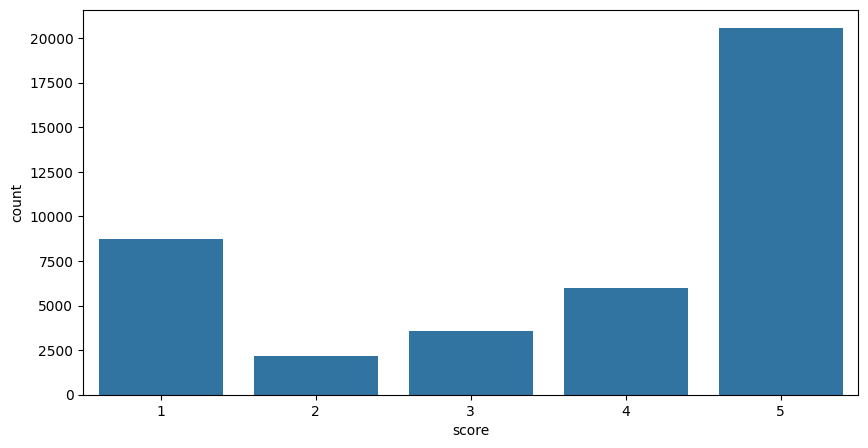

In [89]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x='score', data=df_comments, ax=ax)
plt.show()

N-grams

In [90]:
def ngrams_count(corpus, ngram_range, n=-1, cached_stopwords=pt_stopwords):
    # Using CountVectorizer to build a bag of words using the given corpus
    vectorizer = CountVectorizer(stop_words=cached_stopwords, ngram_range=ngram_range).fit(corpus)
    bag_of_words = vectorizer.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    total_list = words_freq[:n]
    
    # Returning a DataFrame with the ngrams count
    count_df = pd.DataFrame(total_list, columns=['ngram', 'count'])
    return count_df

In [91]:
X_processed = tfidf_features
score_map = {
    1: 'negative',
    2: 'negative',
    3: 'negative',
    4: 'positive',
    5: 'positive'
}
score = df_comments['score'].map(score_map)
y = score.apply(lambda x: 1 if x == 'positive' else 0).values

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test
)
print(f'Length of X_train: {len(X_train)} - Length of one element: {len(X_train[0])}')
print(f'Length of X_test: {len(X_test)} - Length of one element: {len(X_test[0])}')

Length of X_train: 32781 - Length of one element: 300
Length of X_test: 4098 - Length of one element: 300


# Sentiment Classification

In [92]:
# Logistic Regression hyperparameters
logreg_param_grid = {
    'C': np.linspace(0.1, 10, 20),
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced', None],
    'random_state': [42],
    'solver': ['liblinear']
}

svm_param_grid = {
    'C': np.logspace(-2, 2, 10),
    'kernel': ['linear'],
    'class_weight': ['balanced', None],
    'random_state': [42]
}

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'gamma': [0, 0.1, 0.3],
    'random_state': [42]
}

# Setting up the classifiers
set_classifiers = {
    'XGBoost': {
        'model': XGBClassifier(eval_metric='mlogloss'),  # 适用于多分类任务
        'params': xgb_param_grid
    },
    'LogisticRegression': {
        'model': LogisticRegression(),
        'params': logreg_param_grid
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {}
    },
    'SVM': {
        'model': SVC(),
        'params': svm_param_grid
    }
}

In [93]:
best_models = {}

for name, clf_info in set_classifiers.items():
    print(f"Training {name}...")
    
    model = clf_info['model']
    param_grid = clf_info['params']

    if name in ["LogisticRegression", "SVM", "XGBoost"]:
        best_score = 0
        best_params = None
        best_model = None

        for params in ParameterSampler(param_grid, n_iter=10, random_state=42):  # 随机选择 10 组参数
            model.set_params(**params)  # 设置超参数
            model.fit(X_train, y_train)  # 训练
            score = model.score(X_val, y_val)  # 在验证集上评估
            
            if score > best_score:
                best_score = score
                best_params = params
                best_model = model
        
        # 用最佳超参数重新训练模型
        best_model.fit(X_train, y_train)
        best_models[name] = best_model
        print(f"Best parameters for {name}: {best_params}\n")

    #  Naive Bayes 没有超参数调优，直接训练
    else:
        model.fit(X_train, y_train)
        best_models[name] = model
        
    best_models[name] = model


Training XGBoost...
Best parameters for XGBoost: {'subsample': 0.7, 'random_state': 42, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.3, 'gamma': 0.1, 'colsample_bytree': 1.0}

Training LogisticRegression...
Best parameters for LogisticRegression: {'solver': 'liblinear', 'random_state': 42, 'penalty': 'l2', 'class_weight': None, 'C': 3.747368421052632}

Training Naive Bayes...
Training SVM...
Best parameters for SVM: {'random_state': 42, 'kernel': 'linear', 'class_weight': 'balanced', 'C': 0.5994842503189408}




 Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.84      0.77      0.81      1445
           1       0.88      0.92      0.90      2653

    accuracy                           0.87      4098
   macro avg       0.86      0.85      0.85      4098
weighted avg       0.87      0.87      0.87      4098

 Macro Accuracy: 0.8482



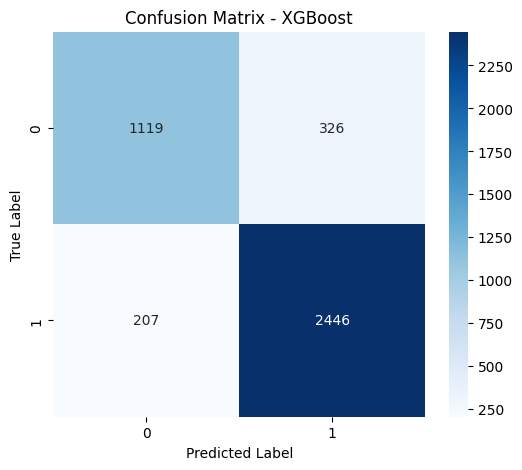


 Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83      1445
           1       0.92      0.88      0.90      2653

    accuracy                           0.87      4098
   macro avg       0.86      0.87      0.87      4098
weighted avg       0.88      0.87      0.88      4098

 Macro Accuracy: 0.8730



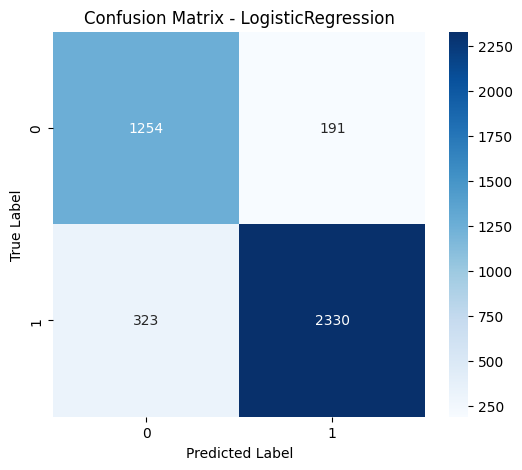


 Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           0       0.76      0.86      0.81      1445
           1       0.92      0.85      0.88      2653

    accuracy                           0.86      4098
   macro avg       0.84      0.86      0.85      4098
weighted avg       0.86      0.86      0.86      4098

 Macro Accuracy: 0.8568



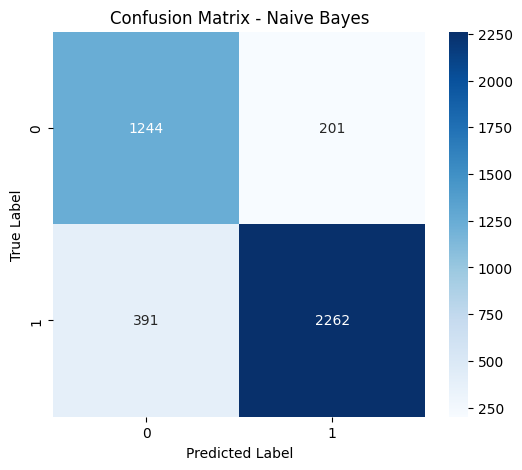


 Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83      1445
           1       0.93      0.87      0.90      2653

    accuracy                           0.88      4098
   macro avg       0.86      0.88      0.87      4098
weighted avg       0.88      0.88      0.88      4098

 Macro Accuracy: 0.8768



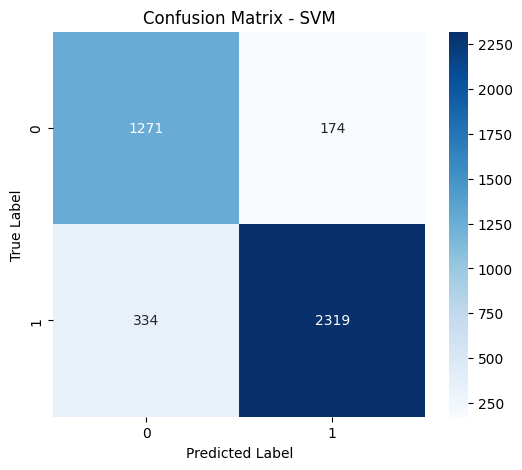

In [94]:
labels = ["0", "1"]
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # 计算每个类别的 accuracy
    class_accuracies = []
    for i in range(len(cm)):
        TP = cm[i, i]  # 该类别的正确预测数量
        FN = np.sum(cm[i, :]) - TP

        class_accuracy = TP / (TP + FN) if (TP + FN) > 0 else 0
        class_accuracies.append(class_accuracy)

    # 计算 macro accuracy
    macro_accuracy = np.mean(class_accuracies)
    
    print(f"\n Classification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=["0", "1"]))
    print(f" Macro Accuracy: {macro_accuracy:.4f}\n")
    
    # 绘制混淆矩阵
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()